In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from keras.layers import Dense, SimpleRNN, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler

In [4]:
df = pd.read_csv("Ecommerce_Sales_Dataset.csv")
df

,Date,Product_Category,Price,Discount,Customer_Segment,Marketing_Spend,Units_Sold
0,01/01/2023,Sports,932.80,35.82,Occasional,6780.38,32
1,02/01/2023,Toys,569.48,3.60,Premium,6807.56,16
2,03/01/2023,Home Decor,699.68,3.56,Premium,3793.91,27
3,04/01/2023,Toys,923.27,0.61,Premium,9422.75,29
4,05/01/2023,Toys,710.17,47.83,Premium,1756.83,17
...,...,...,...,...,...,...,...
995,22/09/2025,Fashion,740.06,49.06,Regular,1890.83,34
996,23/09/2025,Electronics,517.10,28.48,Premium,8011.66,21
997,24/09/2025,Electronics,683.43,12.98,Occasional,3408.51,19
998,25/09/2025,Sports,51.26,21.85,Occasional,7335.62,26


In [5]:
df = pd.get_dummies(df, columns=['Product_Category', 'Customer_Segment'])
df

,Date,Price,Discount,Marketing_Spend,Units_Sold,Product_Category_Electronics,Product_Category_Fashion,Product_Category_Home Decor,Product_Category_Sports,Product_Category_Toys,Customer_Segment_Occasional,Customer_Segment_Premium,Customer_Segment_Regular
0,01/01/2023,932.80,35.82,6780.38,32,False,False,False,True,False,True,False,False
1,02/01/2023,569.48,3.60,6807.56,16,False,False,False,False,True,False,True,False
2,03/01/2023,699.68,3.56,3793.91,27,False,False,True,False,False,False,True,False
3,04/01/2023,923.27,0.61,9422.75,29,False,False,False,False,True,False,True,False
4,05/01/2023,710.17,47.83,1756.83,17,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,22/09/2025,740.06,49.06,1890.83,34,False,True,False,False,False,False,False,True
996,23/09/2025,517.10,28.48,8011.66,21,True,False,False,False,False,False,True,False
997,24/09/2025,683.43,12.98,3408.51,19,True,False,False,False,False,True,False,False
998,25/09/2025,51.26,21.85,7335.62,26,False,False,False,True,False,True,False,False


In [6]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
target = pd.DataFrame(df['Units_Sold'])
target.index = df['Date']
target

,Units_Sold
Date,
2023-01-01,32
2023-01-02,16
2023-01-03,27
2023-01-04,29
2023-01-05,17
...,...
2025-09-22,34
2025-09-23,21
2025-09-24,19


<Axes: xlabel='Date'>

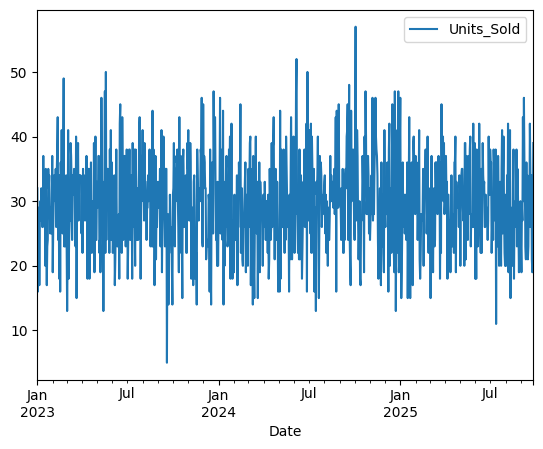

In [7]:
target.plot()

In [8]:
X = df.drop(['Units_Sold', 'Date',], axis=1)
y = df["Units_Sold"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
selector = SelectKBest(f_regression, k=7)

selector.fit(X_train, y_train)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)
model = LinearRegression()
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Selected features:", X.columns[selector.get_support()])
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

Selected features: Index(['Price', 'Discount', 'Product_Category_Fashion',
       'Product_Category_Sports', 'Product_Category_Toys',
       'Customer_Segment_Occasional', 'Customer_Segment_Premium'],
      dtype='object')
MAE: 5.616964045672119
MSE: 50.23345334562086
RMSE: 7.087556232272225
R2: -0.03388723717870579


In [9]:
X = df.drop(['Units_Sold', 'Date',], axis=1)
y = df["Units_Sold"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
sfs = SequentialFeatureSelector(model, n_features_to_select=5, direction='forward')
model = LinearRegression()
sfs.fit(X_train, y_train)
selected_features = X.columns[sfs.get_support()]
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Selected features:", selected_features)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

Selected features: Index(['Price', 'Marketing_Spend', 'Product_Category_Fashion',
       'Product_Category_Toys', 'Customer_Segment_Premium'],
      dtype='object')
MAE: 5.839323262721914
MSE: 54.425476046108614
RMSE: 7.3773624044172195
R2: -0.0063179954821686035


In [10]:
moving_average = target.rolling(window=3).mean()
y_true = target.loc[moving_average.dropna().index]
y_pred = moving_average.loc[moving_average.dropna().index]
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_true, y_pred)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 4.734134936539745
MSE: 35.63571587619684
RMSE: 5.96956580298742
R2: 0.3236036343855344


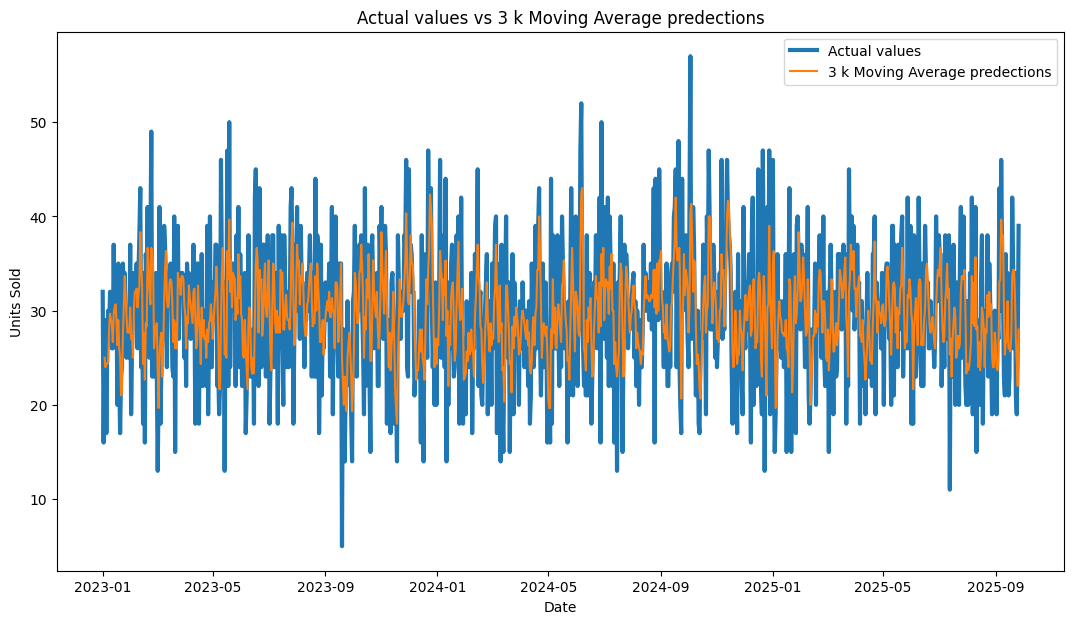

In [11]:
plt.figure(figsize = (13,7))
plt.plot(target,label='Actual values',linewidth=3)
plt.plot(moving_average,label='3 k Moving Average predections',linewidth=1.5)
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.title('Actual values vs 3 k Moving Average predections')
plt.legend()

In [12]:
incods = df.select_dtypes(include=['bool']).columns

df[incods] = df[incods].astype(int)
df.head()

,Date,Price,Discount,Marketing_Spend,Units_Sold,Product_Category_Electronics,Product_Category_Fashion,Product_Category_Home Decor,Product_Category_Sports,Product_Category_Toys,Customer_Segment_Occasional,Customer_Segment_Premium,Customer_Segment_Regular
0,2023-01-01,932.80,35.82,6780.38,32,0,0,0,1,0,1,0,0
1,2023-01-02,569.48,3.60,6807.56,16,0,0,0,0,1,0,1,0
2,2023-01-03,699.68,3.56,3793.91,27,0,0,1,0,0,0,1,0
3,2023-01-04,923.27,0.61,9422.75,29,0,0,0,0,1,0,1,0
4,2023-01-05,710.17,47.83,1756.83,17,0,0,0,0,1,0,1,0


In [13]:
scaler = MinMaxScaler()
df[['Price', 'Discount', 'Marketing_Spend', 'Units_Sold']] = scaler.fit_transform(df[['Price', 'Discount', 'Marketing_Spend', 'Units_Sold']])

In [14]:
X = df.drop(['Units_Sold', 'Date',], axis=1)
y = df["Units_Sold"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train = X_train.values.astype(np.float32)
X_test = X_test.values.astype(np.float32)
X_train = np.expand_dims(X_train, axis=1)
X_test = np.expand_dims(X_test, axis=1)

model = Sequential([LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),Dense(1)])

model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1494 - val_loss: 0.0487
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0433 - val_loss: 0.0262
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0245 - val_loss: 0.0247
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0218 - val_loss: 0.0226
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0222 - val_loss: 0.0221
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0247 - val_loss: 0.0213
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0205 - val_loss: 0.0210
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0214 - val_loss: 0.0203
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0186 - val_loss: 0.0201
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0212 - val_loss: 0.0197
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0196 - val_loss: 0.0194
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0216 - val_loss: 0.0192

In [15]:
loss = model.evaluate(X_test, y_test)
print(loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0194 
0.019117094576358795


In [16]:
y_pred = model.predict(X_test).flatten()
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
MAE: 0.10928545652673793
MSE: 0.019117095794945603
RMSE: 0.13826458619236381
R2: -0.06391943580626092


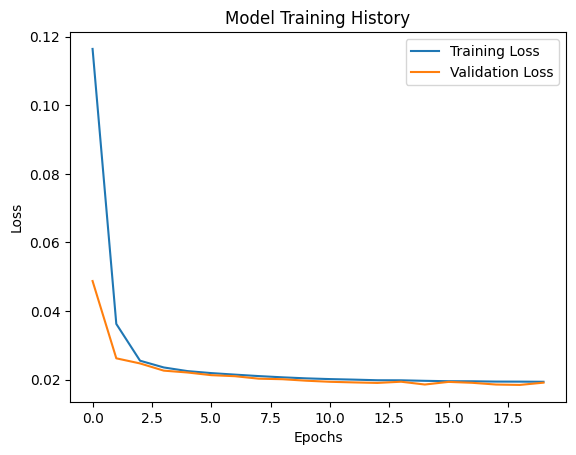

In [17]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Training History')
plt.show()